In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
np.random.seed()

In [35]:
def step_function(x):
    if x >= 0:
        return 1
    return 0

In [36]:
def prediction(X, W, b):
    return step_function((np.matmul(X, W) +b)[0])

In [37]:
def perceptron_step(X, y, W, b, learn_rate=0.05):
    for i in range(0, len(X)):
        y_hat = prediction(X[i], W, b)
        if y[i] - y_hat == 1:
            W[0] += X[i][0] * learn_rate
            W[1] += X[i][1] * learn_rate
            b += learn_rate
        elif y[i] - y_hat == -1:
            W[0] -= X[i][0] * learn_rate
            W[1] -= X[i][1] * learn_rate
            b -= learn_rate
    return W, b

In [38]:
def train_perceptron_algorithm(x, y, learn_rate=0.05, num_epochs=40):
    x_min, x_max = min(x.T[0]), max(x.T[0])
    y_min, y_max = min(x.T[1]), max(x.T[1])
    
    W = np.array(np.random.rand(2, 1))
    b = np.random.rand(1)[0] + x_max
    
    boundary_lines = []
    for i in range (1, num_epochs+1):
        W, b = perceptron_step(x, y, W, b, learn_rate=learn_rate)
        boundary_lines.append((-W[0]/W[1], -b/W[1]))
        
    return boundary_lines, W, b

In [ ]:
data = pd.read_csv("data/perceptron_data.csv", header=None)

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       100 non-null    float64
 1   1       100 non-null    float64
 2   2       100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [41]:
x = np.column_stack([data[0], data[1]])

In [42]:
print(x[:5])

[[ 0.78051  -0.063669]
 [ 0.28774   0.29139 ]
 [ 0.40714   0.17878 ]
 [ 0.2923    0.4217  ]
 [ 0.50922   0.35256 ]]


In [43]:
y = np.array(data[2])

In [44]:
y.shape

(100,)

In [45]:
train_perceptron_algorithm(x, y)

([(array([-0.09205816]), array([0.4579755])),
  (array([-0.14815828]), array([0.46954908])),
  (array([-0.20716734]), array([0.48172278])),
  (array([-0.27253017]), array([0.4942297])),
  (array([-0.34137748]), array([0.50740336])),
  (array([-0.37602003]), array([0.61485293])),
  (array([-0.39270509]), array([0.61554269])),
  (array([-0.40942762]), array([0.616234])),
  (array([-0.45746729]), array([0.62707512])),
  (array([-0.50722752]), array([0.63830452])),
  (array([-0.57900716]), array([0.6590789])),
  (array([-0.61546919]), array([0.67120817])),
  (array([-0.65329843]), array([0.68379225])),
  (array([-0.62718817]), array([0.67282899])),
  (array([-0.60928623]), array([0.66532371])),
  (array([-0.64666277]), array([0.67768607])),
  (array([-0.62088742]), array([0.6669162])),
  (array([-0.5959185]), array([0.65648329])),
  (array([-0.57878716]), array([0.6493363])),
  (array([-0.61469644]), array([0.66110643])),
  (array([-0.59003768]), array([0.6508531])),
  (array([-0.56613212]

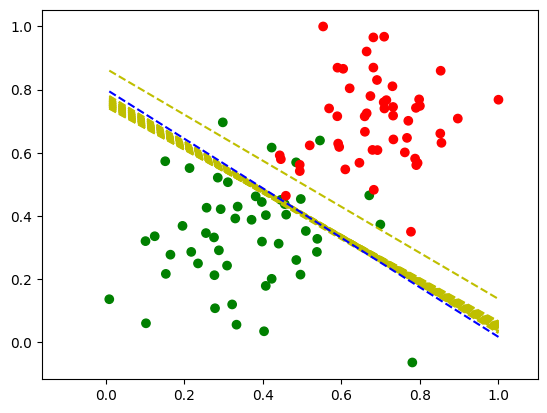

In [46]:
boundary_lines, W_bar, b_bar = train_perceptron_algorithm(x, y)
colors = ["green" if label else "red" for label in y]

plt.scatter(x[:, 0], x[:, 1], c=colors)

x_values = np.linspace(np.min(x[:, 0]), np.max(x[:, 0]), num=100)
for i, W_b in enumerate(boundary_lines, 1):
    if i == len(boundary_lines):
        y_values = W_b[0] * x_values + W_b[1]
        plt.plot(x_values, y_values, "b--")
        continue
    y_values = W_b[0] * x_values + W_b[1]
    plt.plot(x_values, y_values, "y--")

plt.xlim(min(x[:, 0])-0.1, max(x[:, 0]+0.1))
plt.xlim(min(x[:, 1])-0.1, max(x[:, 1]+0.1))
plt.show()

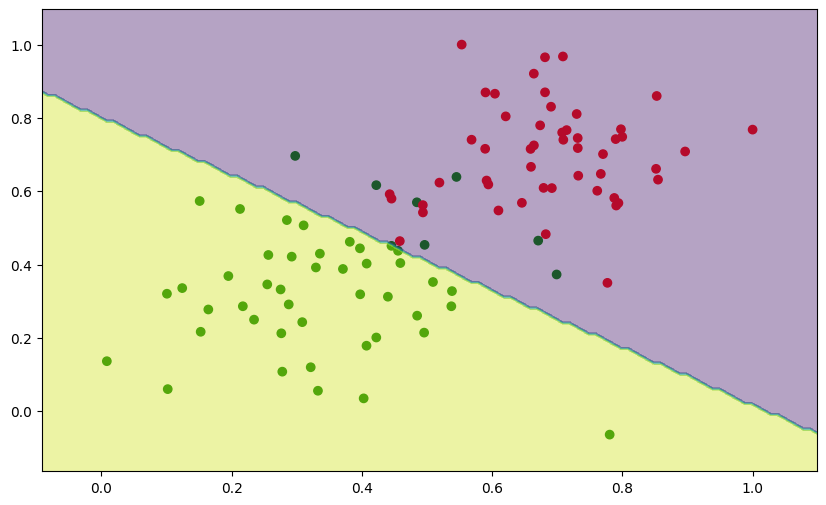

In [48]:
x_min, x_max = min(x.T[0])-0.1, max(x.T[1])+0.1
y_min, y_max = min(x.T[1])-0.1, max(x.T[1])+0.1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

def predict(inputs):
    return step_function((np.matmul(inputs, W_bar) + b_bar)[0])

z = np.array([predict(np.array([xx1, yy1]).reshape(1, -1)) for xx1, yy1 in zip(np.ravel(xx), np.ravel(yy))])
z = z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], x[:, 1], c=colors)
plt.contourf(xx, yy, z, alpha=0.4)
plt.show()